(800, 12)
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic       114.0        177.0           0   
4   37    1      non_anginal  

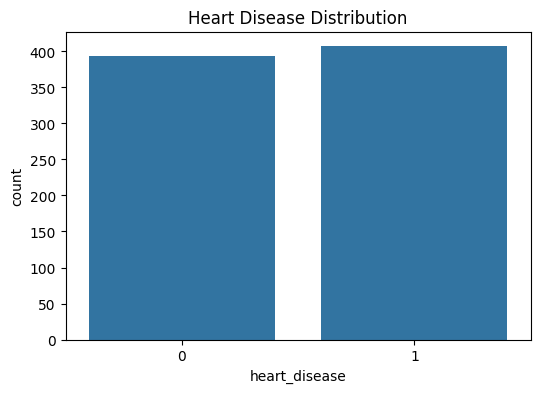

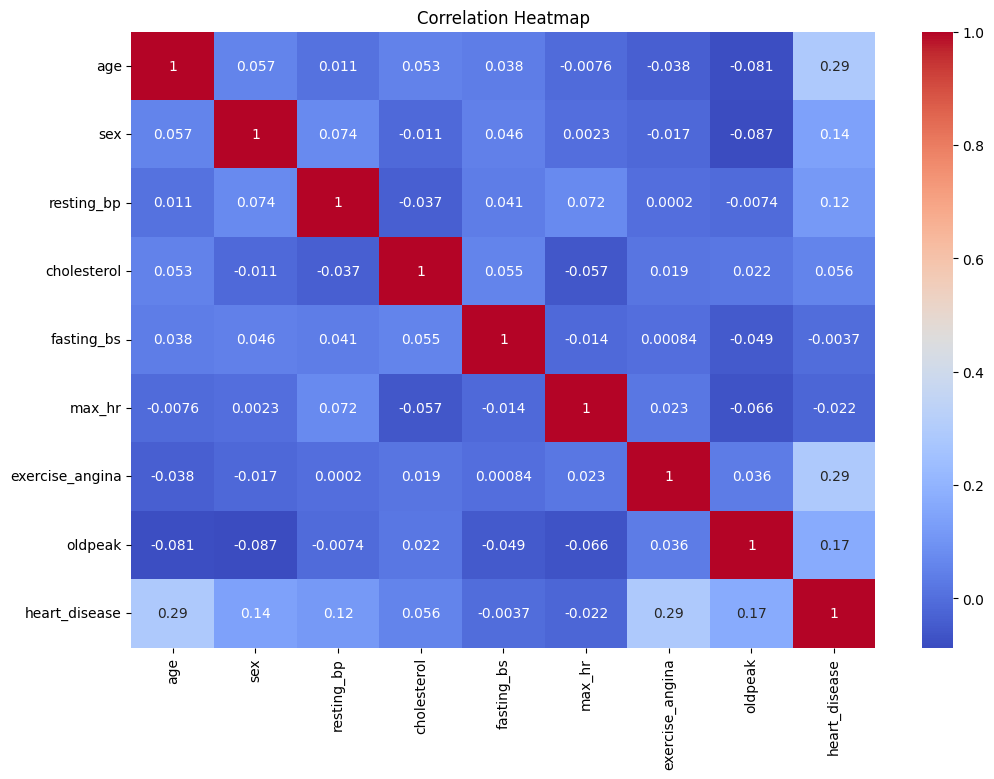

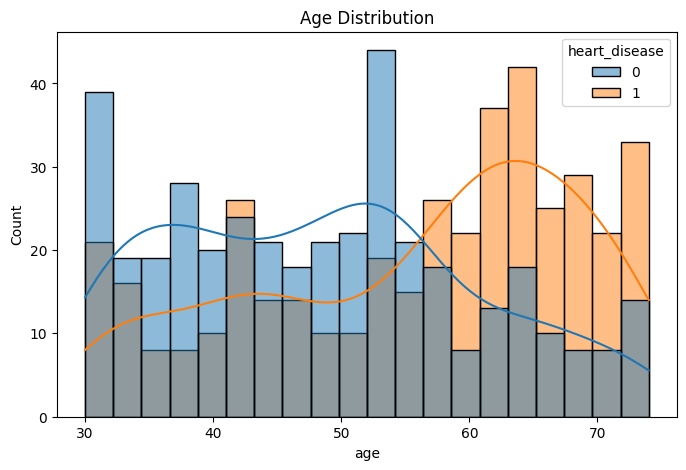

C:\Users\91821\AppData\Local\Temp\ipykernel_8740\1123021328.py:44: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


Decision Tree
[[56 23]
 [22 59]]
Precision: 0.7195121951219512
Recall: 0.7283950617283951
F1 Score: 0.7239263803680982
              precision    recall  f1-score   support

           0       0.72      0.71      0.71        79
           1       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160

Random Forest
[[60 19]
 [15 66]]
Precision: 0.7764705882352941
Recall: 0.8148148148148148
F1 Score: 0.7951807228915663
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        79
           1       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

Gradient Boosting
[[61 18]
 [18 63]]
Precision: 0.7777777777777778
Recall: 0.7777777777777778
F1 Score: 0.77

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

df = pd.read_csv("../data/q1_heart_disease.csv")

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.head())

plt.figure(figsize=(6,4))
sns.countplot(x="heart_disease", data=df)
plt.title("Heart Disease Distribution")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="heart_disease", kde=True, bins=20)
plt.title("Age Distribution")
plt.show()

X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = f1

    print(name)
    print(confusion_matrix(y_test, y_pred))
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print(classification_report(y_test, y_pred))

best_model_name = max(results, key=results.get)

print("Best Model:", best_model_name)

if best_model_name == "Random Forest":

    base_model = RandomForestClassifier(random_state=42)

    param_grid = {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5]
    }

elif best_model_name == "Decision Tree":

    base_model = DecisionTreeClassifier(random_state=42)

    param_grid = {
        "model__max_depth": [3, 5, 10, None],
        "model__min_samples_split": [2, 5, 10]
    }

else:

    base_model = GradientBoostingClassifier(random_state=42)

    param_grid = {
        "model__n_estimators": [50, 100, 150],
        "model__learning_rate": [0.01, 0.1, 0.2],
        "model__max_depth": [3, 5]
    }

tuned_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", base_model)
])

grid = GridSearchCV(
    tuned_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

y_pred_tuned = grid.predict(X_test)

print(confusion_matrix(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))